图像匹配：找到不同图像中相同或相似物体的对应位置关系

**单目标模板匹配**

In [1]:
from utils import *

import cv2
from matplotlib import pyplot as plt
import numpy as np

# 计算互相关
def CCORR(img, temp):
    w, h = temp.shape[::-1]
    W, H = img.shape[::-1]
    img = np.array(img, dtype='float')
    temp = np.array(temp, dtype='float')
    res = np.zeros((W - w + 1, H - h + 1))
    
    # 利用循环计算互相关的值
    for i in range(W - w + 1):
        for j in range(H - h + 1):
            res[i, j] = np.sum(temp * img[j:j + h, i:i + w])
    return res
    

# 构建单目标匹配类
class temp_match_single():
    def __init__(self, img, temp):
        self.img = img
        self.temp = temp
        
    def match(self):
        # 输入目标图像
        img = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        # 输入模板图像
        temp = cv2.cvtColor(self.temp, cv2.COLOR_BGR2GRAY)
        w, h = temp.shape[::-1]
        
        # 计算互相关
        res = CCORR(img, temp)
        
        # 找到互相关值最大的位置
        loc = np.where(res == np.max(res))
        top_left = [int(loc[0]), int(loc[1])]
        bottom_right = (top_left[0] + w, top_left[1] + h)
        
        # 将其框出
        cv2.rectangle(self.img, top_left, bottom_right, (255,255,255), 1)
        plot_image(self.img[:, :, ::-1], 'Matching Result by CCORR')

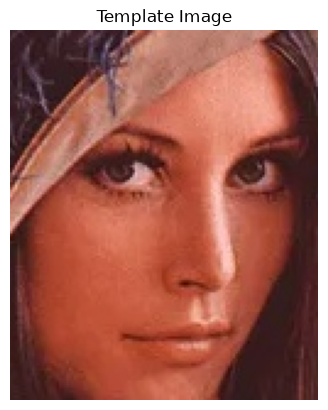

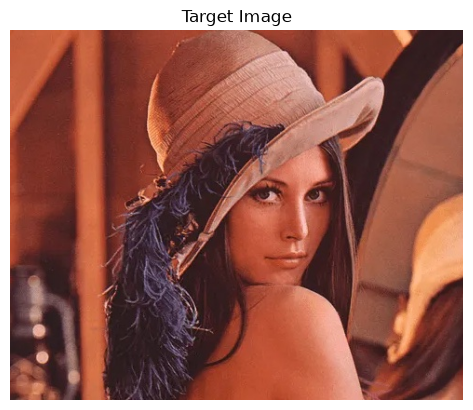

C:\Users\17934\AppData\Local\Temp\ipykernel_39576\1718918523.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  top_left = [int(loc[0]), int(loc[1])]


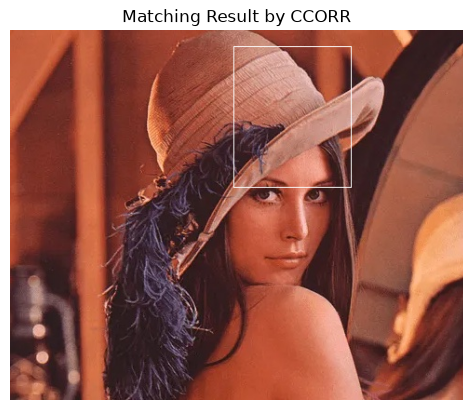

In [2]:
img = cv2.imread('lena_tri.jpg')
template = cv2.imread('lena_small.png')

test = temp_match_single(img, template)
plot_image(test.temp[:, :, ::-1], 'Template Image')
plot_image(test.img[:, :, ::-1], 'Target Image')

test.match()

**归一化互相关**

对模板图像和输入图像进行归一化，从而去除整体像素值大小对互相关结果的影响
$$R(i,j)=\frac{\sum\limits_{m}\sum\limits_{n} I(m,n)\cdot T(m-i,n-j)}
{\sqrt{\sum\limits_{m}\sum\limits_{n} I^2(m,n)}\sqrt{\sum\limits_{m}\sum\limits_{n} T^2(m-i,n-j)}}$$

本质：余弦夹角

C:\Users\17934\AppData\Local\Temp\ipykernel_39576\1718918523.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  top_left = [int(loc[0]), int(loc[1])]


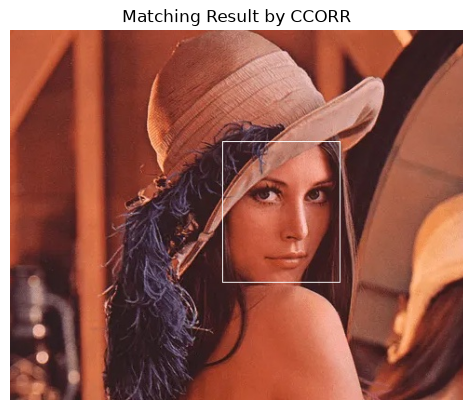

In [3]:
def CCORR(img, temp, normalize=True):
    w, h = temp.shape[::-1]
    W, H = img.shape[::-1]
    res = np.zeros((W-w+1, H-h+1))
    img = np.array(img, dtype='float')
    temp = np.array(temp, dtype='float')
    t = np.sqrt(np.sum(temp**2))
    for i in range(W-w+1):
        for j in range(H-h+1):
            res[i,j] = np.sum(temp*img[j:j+h, i:i+w])
            # 在这里进行归一化操作
            if normalize:
                res[i,j] = res[i,j] / t / np.sqrt(np.sum(img[j:j+h, i:i+w]**2)) 
    return res
    
img = cv2.imread('lena_tri.jpg')
template = cv2.imread('lena_small.png')

test = temp_match_single(img, template)

test.match()

**多目标模板匹配**

In [5]:
import numpy as np

def findKth(s, k):
    return findKth_c(s, 0, len(s) - 1, k)


def findKth_c(s, low, high, k):
    m = partition(s, low, high)
    if m == len(s) - k:
        return s[m]
    elif m < len(s) - k:
        return findKth_c(s, m + 1, high, k)
    else:
        return findKth_c(s, low, m - 1, k)


def partition(s, low, high):
    pivot, j = s[low], low
    for i in range(low + 1, high + 1):
        if s[i] <= pivot:
            j += 1
            s[i], s[j] = s[j], s[i]
    s[j], s[low] = s[low], s[j]
    return j


# 构建多目标模板匹配类
class temp_match_multi():
    def __init__(self, img, temp, k):
        self.img = img
        self.temp = temp
        # 定义需要匹配的个数
        self.k = k
        
    def match(self):
        # 输入模板图像和目标图像
        temp = cv2.cvtColor(self.temp, cv2.COLOR_BGR2GRAY)
        img = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)

        w, h = temp.shape[::-1]
        method = eval('cv2.TM_CCORR_NORMED')
        res = cv2.matchTemplate(img, temp, method)
        temp = list(np.array(res).flatten())
        
        # 寻找res中第k大的值
        threshold = findKth(temp, self.k+1)
        print('设定的阈值为：', threshold)
        loc = np.where(res >= threshold)
        
        # 将找到的子图框选出
        for pt in zip(*loc[::-1]):
            cv2.rectangle(self.img, pt, (pt[0] + w, pt[1] + h), (255,255,255), 1)
            plt.imshow(self.img[:, :, ::-1]), plt.xticks([]), plt.yticks([])
        plt.show()

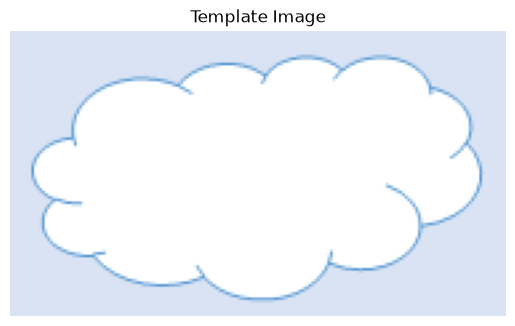

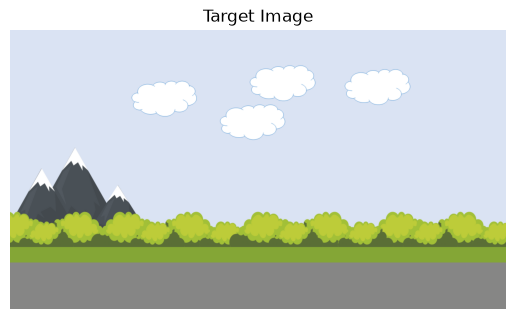

设定的阈值为： 0.9990023


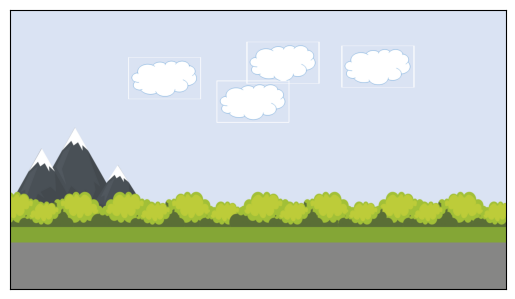

In [8]:
img = cv2.imread('img.png')
template = cv2.imread('temp.png')

test_multi = temp_match_multi(img, template, k=10)
plot_image(test_multi.temp[:, :, ::-1], 'Template Image')
plot_image(test_multi.img[:, :, ::-1], 'Target Image')
test_multi.match()